# 004 - Ablación Ambiental: ¿el ambiente (MP2.5 + clima) mejora la alerta de sobrecarga?

Implementa `specs/004-ablacion-ambiental/plan.md`. Prueba el **elemento original** del proyecto
(Constitución Art. V, VII, VIII): ¿añadir contaminación (MP2.5, SINCA) y clima (temp/precip, DMC)
mejora el modelo base solo-DEIS (inercia del centro + control viral FluNet)?

**Diseño (EVAL-DESIGN §3-4):** modelos incrementales sobre las **mismas filas**, misma partición
temporal (train 2023-24 / test 2025-26) **y** GroupKFold por centro que en 003:
- **A** base · **B** base+MP2.5 · **C** base+MP2.5+clima · **D** base+clima.

Escenario A: **10 comunas** con estación SINCA propia y cobertura 2023-2026 (Independencia queda
fuera: su estación murió en nov-2022). Clima regional de la EMA **Quinta Normal (DMC 330020)**.
**Sin imputación** (Art. V).

## 1. Librerías y rutas

In [1]:
import os, glob, zipfile, datetime as dt, warnings
import pandas as pd, numpy as np, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, auc, f1_score
import shap

BASE = r"c:\Proyectos\Diplomado-ML V2"
PANEL   = os.path.join(BASE,'dataset_salud','urg_resp_centro_semana.parquet')
FLUNET  = os.path.join(BASE,'dataset_salud','flunet_chile_viral_semanal.csv')
MP25DIR = os.path.join(BASE,'dataset_mp25')
DMCDIR  = os.path.join(BASE,'dataset_salud','dmc_raw')

## 2. Ingesta MP2.5 (SINCA) → comuna × semana
Archivos diarios `datos_<comuna>.csv` (coma decimal). Valor = **validados** y, si falta, **preliminares**.
Se agrega a la **semana ISO** (= `SemanaEstadistica`, ver §4).

In [2]:
FILES = {'datos_La Florida':13110,'datos_Cerro Navia':13103,"datos_Parque O'Higgins":13101,
 'datos_Talagante':13601,'datos_Puente Alto':13201,'datos_Pudahuel':13124,'datos_Las Condes':13114,
 'datos_Cerrillos II':13102,'datos_Quilicura':13125,'datos_El Bosque':13105}
def _val(v):
    v=v.strip().replace(',','.'); return float(v) if v else np.nan
rows=[]
for stem,code in FILES.items():
    for line in open(os.path.join(MP25DIR,stem+'.csv'),encoding='utf-8',errors='replace').read().splitlines()[1:]:
        p=line.split(';')
        if len(p)<4: continue
        f=p[0].strip().strip('"')
        if len(f)!=6 or not f.isdigit(): continue
        d=dt.date(2000+int(f[:2]),int(f[2:4]),int(f[4:6])); v=_val(p[2])
        if np.isnan(v): v=_val(p[3])
        if not np.isnan(v): rows.append((code,d,v))
mp=pd.DataFrame(rows,columns=['ComunaCodigo','fecha','mp25'])
iso=mp['fecha'].apply(lambda d:d.isocalendar()); mp['Anio']=[t[0] for t in iso]; mp['SemanaEstadistica']=[t[1] for t in iso]
amb=(mp.groupby(['ComunaCodigo','Anio','SemanaEstadistica']).agg(mp25_prom=('mp25','mean'),mp25_max=('mp25','max'),
      n_dias_preemergencia=('mp25',lambda s:int((s>=110).sum()))).reset_index())
amb.to_parquet(os.path.join(BASE,'dataset_salud','ambiente_comuna_semana.parquet'))
print(f"MP2.5 -> {amb.shape} | comunas={amb.ComunaCodigo.nunique()}")

MP2.5 -> (9639, 6) | comunas=10


## 2b. Ingesta clima (DMC — EMA Quinta Normal 330020) → semana
Datos por minuto. **Temperatura:** `ts` (temp aire) → tmín diaria = min. **Agua Caída:** `rr24Horas`
(acumulado 24h) tomado a las ~12:00 → precip diaria (ventanas no solapadas). Clima **regional**
(igual para todas las comunas en cada semana).

In [3]:
def _load(pat,col):
    fr=[]
    for z in sorted(glob.glob(os.path.join(DMCDIR,pat))):
        with zipfile.ZipFile(z) as zf: fr.append(pd.read_csv(zf.open(zf.namelist()[0]),sep=';',usecols=['momento',col]))
    return pd.concat(fr,ignore_index=True)
T=_load('*_Temperatura.csv.zip','ts'); T['dtm']=pd.to_datetime(T['momento'],errors='coerce'); T['ts']=pd.to_numeric(T['ts'],errors='coerce')
T=T.dropna(subset=['dtm','ts']); T['fecha']=T['dtm'].dt.date
tday=T.groupby('fecha')['ts'].min().rename('tmin').reset_index()
P=_load('*_AguaCaida.csv.zip','rr24Horas'); P['dtm']=pd.to_datetime(P['momento'],errors='coerce'); P['rr24']=pd.to_numeric(P['rr24Horas'],errors='coerce')
P=P.dropna(subset=['dtm','rr24']); P['fecha']=P['dtm'].dt.date
P['dist']=(P['dtm'].dt.hour*60+P['dtm'].dt.minute-720).abs()
pday=P.sort_values('dist').groupby('fecha').head(1)[['fecha','precip_dia']] if False else P.sort_values('dist').groupby('fecha').head(1)[['fecha','rr24']].rename(columns={'rr24':'precip_dia'})
cl=tday.merge(pday,on='fecha',how='outer'); iso=cl['fecha'].apply(lambda d:d.isocalendar())
cl['Anio']=[t[0] for t in iso]; cl['SemanaEstadistica']=[t[1] for t in iso]
clw=cl.groupby(['Anio','SemanaEstadistica']).agg(temp_min_prom=('tmin','mean'),
     n_dias_helada=('tmin',lambda s:int((s<0).sum())),precip_acum=('precip_dia','sum')).reset_index()
clw.to_parquet(os.path.join(BASE,'dataset_salud','clima_dmc_semana.parquet'))
s=clw[clw.Anio.isin([2024,2025])].copy(); s['e']=np.where((s.SemanaEstadistica>=23)&(s.SemanaEstadistica<=35),'invierno','resto')
print(f"clima -> {clw.shape}\nSanity estacional (2024-25):"); print(s.groupby('e')[['temp_min_prom','precip_acum']].mean().round(2).to_string())

clima -> (184, 5)
Sanity estacional (2024-25):
          temp_min_prom  precip_acum
e                                   
invierno           4.23        15.60
resto             10.14         2.89


## 3. Verificación: `SemanaEstadistica` == semana ISO
`pos_vrs` del panel debe coincidir **exacto** con FluNet SENTINEL (`RSV/RSV_PROCESSED`) por `ISO_YEAR/ISO_WEEK`.

In [4]:
pchk=pd.read_parquet(PANEL)[['Anio','SemanaEstadistica','pos_vrs']].drop_duplicates().dropna()
fl=pd.read_csv(FLUNET); fl.columns=[c.upper() for c in fl.columns]
sfl=fl[fl['ORIGIN_SOURCE']=='SENTINEL'].copy(); sfl['pv']=sfl['RSV']/sfl['RSV_PROCESSED']
m=pchk.merge(sfl[['ISO_YEAR','ISO_WEEK','pv']],left_on=['Anio','SemanaEstadistica'],right_on=['ISO_YEAR','ISO_WEEK'])
print(f"Coincidencias exactas: {int((np.abs(m.pos_vrs-m.pv)<1e-6).sum())}/{len(m)} | corr={m[['pos_vrs','pv']].corr().iloc[0,1]:.4f} -> semana ISO")

Coincidencias exactas: 130/182 | corr=1.0000 -> semana ISO


## 4. Cruce con el panel + features (base + MP2.5 + clima, rezagados, **sin imputar**)
Filas de evaluación **idénticas** para A/B/C/D (solo donde MP2.5 y clima rezagados existen).

In [5]:
panel=pd.read_parquet(PANEL); panel['ComunaCodigo']=panel['ComunaCodigo'].astype(int)
df=panel[panel['ComunaCodigo'].isin(FILES.values())].sort_values(['EstablecimientoCodigo','Anio','SemanaEstadistica']).copy()
flg=['n_atenciones','pos_vrs','pos_flu','n_0a4','n_5a14','n_65mas']
for c in flg:
    for l in [1,2,3]: df[f'{c}_lag{l}']=df.groupby('EstablecimientoCodigo')[c].shift(l)
# v3: features sin fuga IDÉNTICAS a 003 (base reforzada) — la ablación mide el aporte del ambiente SOBRE esta base
g=df.groupby('EstablecimientoCodigo')['n_atenciones']
df['roll_mean4']=g.transform(lambda x:x.shift(1).rolling(4,min_periods=2).mean())
df['roll_std4'] =g.transform(lambda x:x.shift(1).rolling(4,min_periods=2).std())
df['z_lag1']=(df['n_atenciones_lag1']-df['roll_mean4'])/(df['roll_std4']+1e-6)
df['mom_1_2']=df['n_atenciones_lag1']-df['n_atenciones_lag2']
df['mom_2_3']=df['n_atenciones_lag2']-df['n_atenciones_lag3']
df['d_flu']=df['pos_flu_lag1']-df['pos_flu_lag2']; df['d_vrs']=df['pos_vrs_lag1']-df['pos_vrs_lag2']
df['n_hosp_resp_lag1']=df.groupby('EstablecimientoCodigo')['n_hosp_resp'].shift(1)
df['sem_sin']=np.sin(2*np.pi*df['SemanaEstadistica']/52.0); df['sem_cos']=np.cos(2*np.pi*df['SemanaEstadistica']/52.0)
df=df.dropna(subset=['alta_demanda']+[f'{c}_lag1' for c in flg])
base=['n_centros_vecinos','n_atenciones_lag1','n_atenciones_lag2','n_atenciones_lag3','pos_vrs_lag1','pos_vrs_lag2','pos_flu_lag1','pos_flu_lag2','n_0a4_lag1','n_65mas_lag1','z_lag1','mom_1_2','mom_2_3','d_flu','d_vrs','n_hosp_resp_lag1','n_5a14_lag1','sem_sin','sem_cos']
df=pd.get_dummies(df,columns=['TipoUrgencia'],drop_first=True); base+=[c for c in df.columns if c.startswith('TipoUrgencia_')]
if 'NivelComplejidad' in df.columns:
    df=pd.get_dummies(df,columns=['NivelComplejidad'],drop_first=True); base+=[c for c in df.columns if c.startswith('NivelComplejidad_')]
df[base]=df[base].fillna(0); df['alta_demanda']=df['alta_demanda'].astype(int)
df=df.merge(amb[['ComunaCodigo','Anio','SemanaEstadistica','mp25_prom','mp25_max']],on=['ComunaCodigo','Anio','SemanaEstadistica'],how='left')
df=df.merge(clw,on=['Anio','SemanaEstadistica'],how='left').sort_values(['EstablecimientoCodigo','Anio','SemanaEstadistica'])
for c in ['mp25_prom','mp25_max','temp_min_prom','n_dias_helada','precip_acum']:
    df[f'{c}_lag1']=df.groupby('EstablecimientoCodigo')[c].shift(1)
df['mp25_prom_lag2']=df.groupby('EstablecimientoCodigo')['mp25_prom'].shift(2)
mp25_feats=['mp25_prom_lag1','mp25_prom_lag2','mp25_max_lag1']; clima_feats=['temp_min_prom_lag1','n_dias_helada_lag1','precip_acum_lag1']
ev=df.dropna(subset=mp25_feats+clima_feats).copy(); tr=ev['Anio'].isin([2023,2024]); te=ev['Anio'].isin([2025,2026])
print(f"Filas ablacion: train={tr.sum()} test={te.sum()} | pos test={ev.loc[te,'alta_demanda'].mean()*100:.1f}% | nº features base={len(base)}")

Filas ablacion: train=4324 test=3214 | pos test=22.0% | nº features base=24


## 5. Ablación incremental A / B / C / D (test temporal + GroupKFold)

In [6]:
def run(feats,name):
    pipe=Pipeline([('sc',StandardScaler()),('lr',LogisticRegression(penalty='l1',solver='liblinear',class_weight='balanced',random_state=42,C=0.1))])
    pipe.fit(ev.loc[tr,feats],ev.loc[tr,'alta_demanda']); pr=pipe.predict_proba(ev.loc[te,feats])[:,1]; pred=pipe.predict(ev.loc[te,feats])
    p,r,_=precision_recall_curve(ev.loc[te,'alta_demanda'],pr)
    g=cross_val_score(pipe,ev[feats],ev['alta_demanda'],groups=ev['EstablecimientoCodigo'],cv=GroupKFold(5),scoring='average_precision')
    print(f"  {name:22} PR-AUC={auc(r,p):.3f}  F1={f1_score(ev.loc[te,'alta_demanda'],pred):.3f}  GKF-AP={g.mean():.3f}+/-{g.std():.3f}")
    return g.mean()
print("=== ABLACION (mismas filas) ===")
gA=run(base,'A base'); gB=run(base+mp25_feats,'B +MP2.5'); gC=run(base+mp25_feats+clima_feats,'C +MP2.5+clima'); gD=run(base+clima_feats,'D +clima')
print(f"\n  Δ GKF-AP vs A:  B={gB-gA:+.3f}  C={gC-gA:+.3f}  D={gD-gA:+.3f}  (ruido entre folds ~0.025)")

=== ABLACION (mismas filas) ===


  A base                 PR-AUC=0.439  F1=0.504  GKF-AP=0.487+/-0.017


  B +MP2.5               PR-AUC=0.438  F1=0.502  GKF-AP=0.487+/-0.019


  C +MP2.5+clima         PR-AUC=0.445  F1=0.503  GKF-AP=0.496+/-0.019


  D +clima               PR-AUC=0.445  F1=0.503  GKF-AP=0.498+/-0.018

  Δ GKF-AP vs A:  B=+0.000  C=+0.009  D=+0.011  (ruido entre folds ~0.025)


## 6. Interpretabilidad SHAP (modelo C, completo): ¿dónde caen las ambientales?

Background dataset has 4324 samples but max_samples=1000. Subsampling to 1000 samples for SHAP value computation. To use all samples, set max_samples=4324 when initializing the masker.


Top 6 SHAP:
z_lag1                0.7927
pos_flu_lag2          0.4183
sem_sin               0.4039
temp_min_prom_lag1    0.3378
sem_cos               0.3166
n_atenciones_lag3     0.2827

Posicion de las ambientales (de 30):
  mp25_prom_lag1         puesto 30 (|phi|=0.0000)
  mp25_prom_lag2         puesto 29 (|phi|=0.0000)
  mp25_max_lag1          puesto 20 (|phi|=0.0012)
  temp_min_prom_lag1     puesto 4 (|phi|=0.3378)
  n_dias_helada_lag1     puesto 18 (|phi|=0.0094)
  precip_acum_lag1       puesto 14 (|phi|=0.0442)


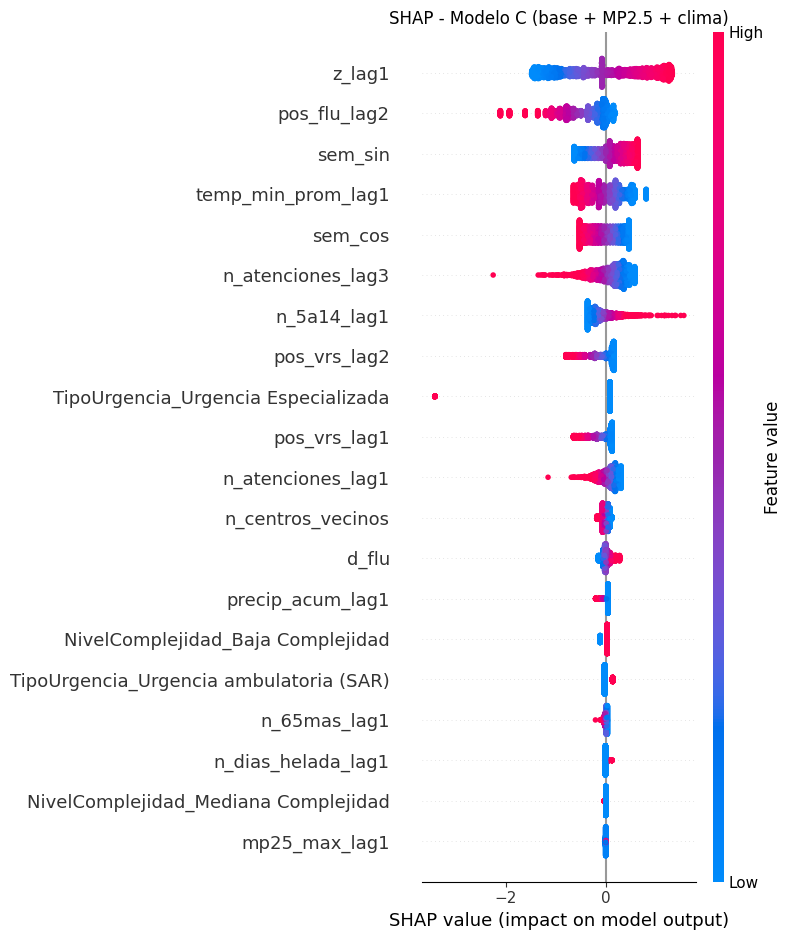

In [7]:
feats=base+mp25_feats+clima_feats
sc=StandardScaler().fit(ev.loc[tr,feats])
lr=LogisticRegression(penalty='l1',solver='liblinear',class_weight='balanced',random_state=42,C=0.1).fit(sc.transform(ev.loc[tr,feats]),ev.loc[tr,'alta_demanda'])
sv=shap.LinearExplainer(lr,shap.maskers.Independent(sc.transform(ev.loc[tr,feats]),max_samples=1000)).shap_values(sc.transform(ev.loc[te,feats]))
imp=pd.Series(np.abs(sv).mean(0),index=feats).sort_values(ascending=False)
print("Top 6 SHAP:"); print(imp.head(6).round(4).to_string())
print("\nPosicion de las ambientales (de %d):"%len(feats))
for f in mp25_feats+clima_feats: print(f"  {f:22} puesto {list(imp.index).index(f)+1} (|phi|={imp[f]:.4f})")
shap.summary_plot(sv,sc.transform(ev.loc[te,feats]),feature_names=feats,show=False)
plt.title('SHAP - Modelo C (base + MP2.5 + clima)'); plt.tight_layout(); plt.show()

## 7. Veredicto (ablación completa, sobre la base reforzada v3)

**Resultado nulo honesto y robusto (Art. VIII):** ni el MP2.5 ni el clima (temp/precip) mejoran el
modelo base de forma significativa, **incluso tras reforzar la base con las features v3** (z-score de
calor reciente, momentum, estacionalidad, etc.). El aporte del ambiente completo es
**ΔGKF-AP ≈ +0.009** (C vs A), dentro del ruido entre folds (±0.025). El MP2.5 queda **último** en
SHAP (|phi|≈0); la temperatura mínima sube al ~4º puesto pero su aporte incremental sigue sin ser
significativo.

**Por qué:** el target mide un *salto sobre la línea base reciente del propio centro* (Art. III) →
modelo fuertemente autorregresivo; y en invierno MP2.5, frío, lluvia y ola viral **co-varían**, así
que el ambiente es redundante con la señal viral y la dinámica local que el base ya captura. Al
reforzar la base (GKF-AP 0.378 → **0.487**), el margen que podría llenar el ambiente se estrecha aún
más.

**Conclusión del proyecto:** el modelo **base solo-DEIS (inercia + dinámica reciente + control viral
FluNet) es suficiente**; el enriquecimiento ambiental del Escenario A **no agrega valor** — resultado
válido y reportable que respalda la parsimonia. Cierra el elemento original del proyecto.